# Exploring spur removal

In [29]:
# imports
from importlib import reload
import os

import numpy as np
import h5py
import xarray
import pandas

from matplotlib import pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import MultipleLocator
import matplotlib.gridspec as gridspec
import seaborn as sns

from skimage import morphology
import scipy.ndimage as ndi

from fronts.dbof import utils as dbof_utils
from fronts.dbof import io as dbof_io
from fronts.finding import dev as finding_dev
from fronts.finding import params as finding_params
from fronts.finding import pyboa as ff_pyboa
from fronts.finding import thin_cc
from fronts.finding import io as finding_io
from fronts.finding import cc_sst_preproc

# Load up fronts

In [5]:
bfronts = finding_io.load_binary_fronts('2012-11-09T12_00_00', 'B', '1')

Loading binary front field from /home/xavier/Projects/Oceanography/tmp/OGCM/LLC/Fronts/outputs/LLC4320_2012-11-09T12_00_00_v1_bin_B.npy


# Region

In [6]:
roi = (slice(9500, 9750), slice(10600, 10900))

# Plot before

In [11]:
def plot_fronts(image):
    fig = plt.figure(figsize=(7,7))
    ax = plt.gca()
    #
    ax.imshow(image, origin='lower', cmap='Greys')
    #
    plt.show()

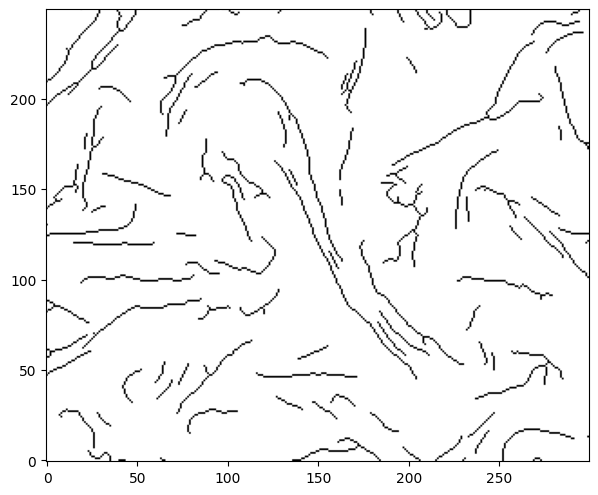

In [13]:
plot_fronts(bfronts[roi])

# Remove spurs

In [23]:
bfront_spurs = ff_pyboa.spur(bfronts[roi], n_iter=6)

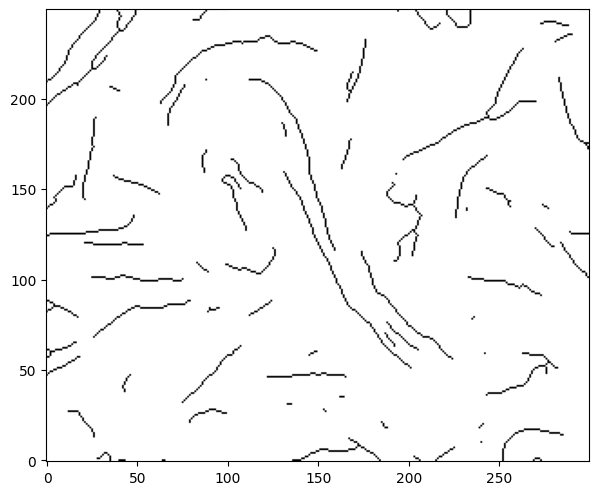

In [24]:
plot_fronts(bfront_spurs)

In [16]:
np.save('bfronts_spurs', bfronts[roi])

# Try cropping

In [25]:
cropped = ff_pyboa.cropping(bfronts[roi])

/home/xavier/Oceanography/python/fronts/fronts/finding/pyboa.py:906: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  frnt = morphology.remove_small_objects(


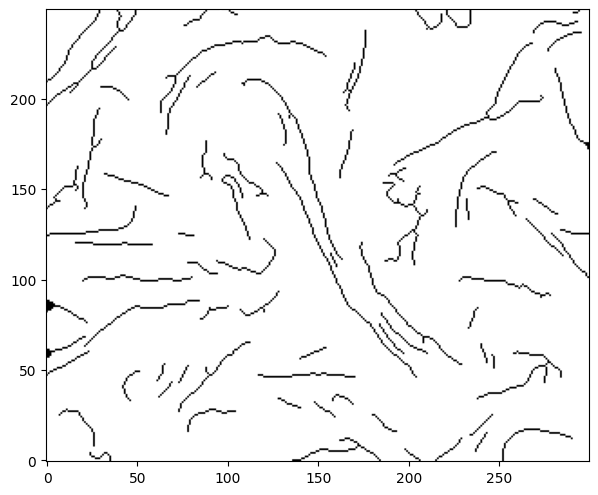

In [26]:
plot_fronts(cropped)

# Dilate+

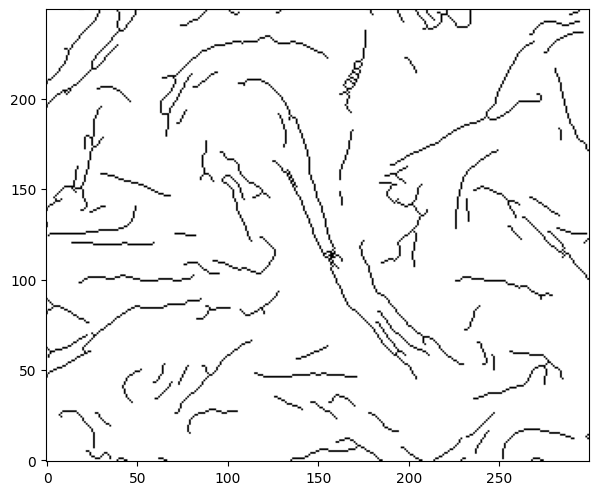

In [28]:
plot_fronts(morphology.thin(morphology.dilation(bfronts[roi])))

# Neighbors

In [32]:
def _neighbors_conv(image):
    """
    Counts the neighbor pixels for each pixel of an image:
            x = [
                [0, 1, 0],
                [1, 1, 1],
                [0, 1, 0]
            ]
            _neighbors(x)
            [
                [0, 3, 0],
                [3, 4, 3],
                [0, 3, 0]
            ]
    :type image: numpy.ndarray
    :param image: A two-or-three dimensional image
    :return: neighbor pixels for each pixel of an image
    """
    image = image.astype(int)
    k = np.array([[1,1,1],[1,0,1],[1,1,1]])
    neighborhood_count = ndi.convolve(image,k, mode='constant', cval=1)
    neighborhood_count[~image.astype(np.bool)] = 0
    return neighborhood_count

In [34]:
nneighbors = _neighbors_conv(bfronts[roi])

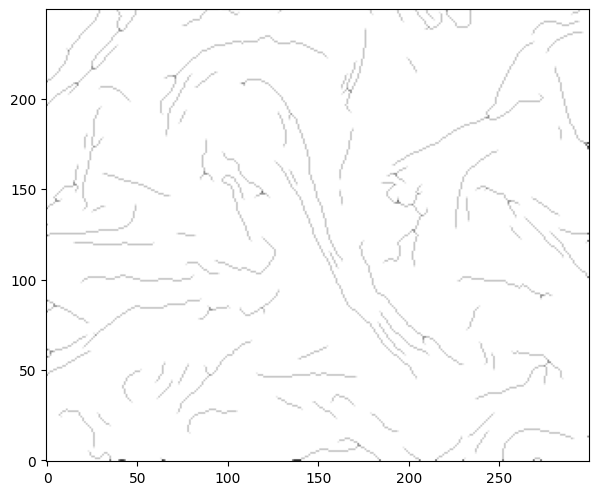

In [35]:
plot_fronts(nneighbors)